# Класифікація: LogisticRegression на Iris dataset

У цьому notebook ви навчите модель `LogisticRegression` розпізнавати вид ірису за 4 числовими ознаками квітки.

## Мета

Побудувати повний classification workflow:

- завантажити датасет з `sklearn.datasets`;
- розділити дані на train/test;
- навчити `LogisticRegression`;
- порахувати Accuracy, Precision, Recall, F1;
- прочитати confusion matrix.

Очікуваний головний результат: accuracy приблизно `0.91`, а основні помилки мають бути між класами `versicolor` і `virginica`.

## Завдання

У notebook є 5 основних місць для самостійного коду:

1. Завантажити `Iris` dataset.
2. Підготувати `X`, `y` і train/test split.
3. Створити pipeline з `StandardScaler` і `LogisticRegression`.
4. Отримати прогнози й порахувати метрики.
5. Побудувати confusion matrix і зробити короткий висновок.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.magics import display

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## Завдання 1. Завантажте Iris dataset

У клітинці нижче:

1. завантажте дані через `load_iris(as_frame=True)`;
2. створіть `df`;
3. додайте колонку `species` з назвами класів;
4. видаліть числову колонку `target`;
5. покажіть розмір таблиці й перші 5 рядків.

In [ ]:
# TODO:
# 1. data = load_iris(as_frame=True)
# 2. df = data.frame.copy()
# 3. df["species"] = df["target"].map(dict(enumerate(data.target_names)))
# 4. df = df.drop(columns="target")
# 5. Виведіть df.shape і df.head()

# data = ...
# df = ...

**Очікуваний результат**

- Розмір таблиці: `(150, 5)`.
- Має бути 4 числові ознаки: `sepal length (cm)`, `sepal width (cm)`, `petal length (cm)`, `petal width (cm)`.
- Цільова колонка: `species` з класами `setosa`, `versicolor`, `virginica`.

## Швидкий огляд даних

Ця клітинка показує баланс класів і базові статистики.

In [3]:
display(df.describe().T)

class_counts = df["species"].value_counts().sort_index()
display(class_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_title("Кількість прикладів у кожному класі")
ax.set_xlabel("species")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.show()

NameError: name 'df' is not defined

Кожен клас має по `50` прикладів. Це збалансований датасет, тому `accuracy` тут можна читати простіше, ніж у задачах з сильним дисбалансом класів.

## Scatter plot для двох ознак

Подивимось, як класи розділяються за довжиною і шириною пелюстки.

NameError: name 'df' is not defined

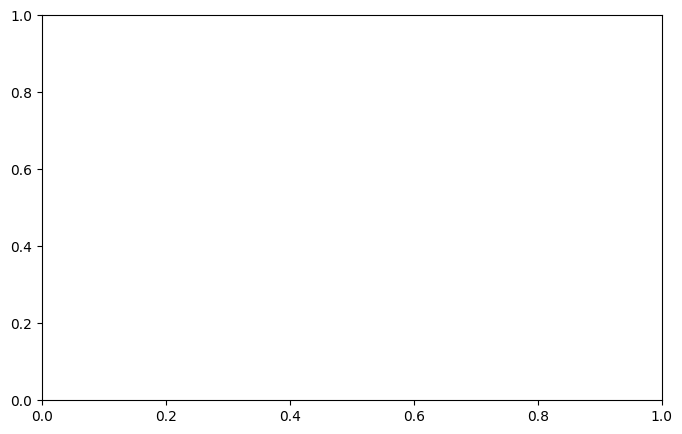

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
for species, part in df.groupby("species"):
    ax.scatter(part["petal length (cm)"], part["petal width (cm)"], alpha=0.8, label=species)

ax.set_title("Iris: petal length vs petal width")
ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
ax.legend(title="species")
plt.show()

`setosa` має добре відділятися від інших класів. `versicolor` і `virginica` частково ближчі один до одного, тому саме між ними модель може робити помилки.

## Завдання 2. Підготуйте X, y і train/test split

`X` має містити всі 4 числові ознаки, а `y` - колонку `species`.

Для split використайте:

```python
test_size=0.30
random_state=RANDOM_STATE
stratify=y
```

In [ ]:
# TODO:
# 1. X = df без колонки species
# 2. y = df["species"]
# 3. Зробіть train_test_split з test_size=0.30, random_state=RANDOM_STATE, stratify=y
# 4. Виведіть розміри X_train і X_test

# X = ...
# y = ...
# X_train, X_test, y_train, y_test = ...

**Очікуваний результат**

- `X_train.shape`: `(105, 4)`.
- `X_test.shape`: `(45, 4)`.
- У тестовій вибірці має бути по `15` прикладів кожного класу.

## Завдання 3. Створіть і навчіть LogisticRegression pipeline

Створіть `Pipeline` з двох кроків:

1. `StandardScaler()`;
2. `LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)`.

Після цього навчіть модель на train data.

In [ ]:
# TODO:
# 1. Створіть pipeline у змінній model
# 2. Навчіть model на X_train, y_train

# model = Pipeline([
#     (...),
#     (...),
# ])
# model.fit(...)



**Очікуваний результат**

Після `model.fit(...)` клітинка має виконатися без warning про `max_iter`. Масштабування потрібне, бо логістична регресія чутлива до масштабу ознак.

## Завдання 4. Отримайте прогнози й порахуйте метрики

Отримайте `y_pred` для тестової вибірки й порахуйте:

- Accuracy;
- Precision macro;
- Recall macro;
- F1 macro.

In [ ]:
# TODO:
# 1. y_pred = model.predict(X_test)
# 2. Порахуйте accuracy_score(y_test, y_pred)
# 3. Порахуйте precision_score(..., average="macro")
# 4. Порахуйте recall_score(..., average="macro")
# 5. Порахуйте f1_score(..., average="macro")
# 6. Зберіть результат у DataFrame metrics і виведіть його

# y_pred = ...
# metrics = pd.DataFrame([...])
# metrics

**Очікуваний результат**

Метрики мають бути приблизно такими:

| metric | value |
|---|---:|
| accuracy | 0.911 |
| precision_macro | 0.916 |
| recall_macro | 0.911 |
| f1_macro | 0.911 |

Невеликі відмінності в останніх знаках можливі.

## Завдання 5. Побудуйте confusion matrix

Побудуйте confusion matrix для класів у такому порядку:

```python
labels = list(data.target_names)
```

Після матриці коротко напишіть, які класи модель плутає найчастіше.

In [ ]:
labels = list(data.target_names)

# TODO:
# 1. cm = confusion_matrix(y_test, y_pred, labels=labels)
# 2. Виведіть cm
# 3. Побудуйте ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# cm = ...

**Очікуваний результат**

Confusion matrix має бути близькою до такої:

```text
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]
```

Інтерпретація:

- `setosa` класифікується без помилок;
- основні помилки між `versicolor` і `virginica`;
- це логічно, бо ці два класи на scatter plot розташовані ближче один до одного.

## Classification report

Ця клітинка виводить детальні метрики по кожному класу.

In [ ]:
print(classification_report(y_test, y_pred, labels=labels))

У `classification_report` для `setosa` precision, recall і F1 мають бути `1.00`. Для `versicolor` і `virginica` метрики нижчі, бо саме між ними є кілька помилок.

## Ймовірності класів

`LogisticRegression` може повертати не тільки клас, а й ймовірності класів через `predict_proba`.

In [ ]:
proba = model.predict_proba(X_test)
proba_df = pd.DataFrame(proba, columns=model.classes_)
proba_df["true_class"] = y_test.reset_index(drop=True)
proba_df["predicted_class"] = y_pred
proba_df.head(10).round(3)

У кожному рядку ймовірності трьох класів мають сумуватися приблизно до `1.0`. Найбільша ймовірність відповідає передбаченому класу.

## Висновок

Модель добре класифікує Iris dataset: accuracy приблизно `0.91`. Клас `setosa` відділяється найкраще, а помилки виникають між `versicolor` і `virginica`. Macro-метрики доречні, бо ми хочемо оцінити якість по кожному класу, а не тільки загальну частку правильних відповідей.